# Template-free zero-crossing residual search

This example fits only the single-lens baseline, then searches the residuals without running the standard bell-template anomaly scan.

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from jacscanomaly import Finder, FinderConfig, TemplateFreeSearchConfig

logging.basicConfig(level=logging.INFO)
logging.getLogger("jax").setLevel(logging.WARNING)

In [2]:
data = np.load(Path("example_data.npy"))
time, flux, ferr = data[:, 0], data[:, 1], data[:, 2]

Fit the single-lens baseline only. This produces residuals for the template-free search without invoking the standard bell-template scan.

In [3]:
finder = Finder(FinderConfig())
fit = finder.fit_single_lens(time, flux, ferr)

Run the template-free detector. It seeds on high-|z| residuals, grows each seed to nearby zero crossings within a season, and keeps windows above the total chi2 threshold.

In [4]:
tf_config = TemplateFreeSearchConfig(
    seed_z_threshold=3.0,
    zero_crossings_each_side=2,
    candidate_chi2_threshold=100.0,
)

tf_result = finder.run_template_free(time, flux, ferr, fit=fit, config=tf_config)

In [5]:
best = tf_result.best

print(f"n candidates: {len(tf_result.candidates)}")
if best is not None:
    print(f"kind      = {best.kind}")
    print(f"t_start   = {best.t_start:.3f}")
    print(f"t_end     = {best.t_end:.3f}")
    print(f"n_points  = {best.n_points}")
    print(f"chi2      = {best.chi2:.2f}")
    print(f"chi2 / n  = {best.reduced_chi2:.2f}")
    print(f"max |z|   = {best.max_abs_z:.2f}")

n candidates: 1
kind      = zero_crossing
t_start   = 9825.790
t_end     = 9826.035
n_points  = 24
chi2      = 121.31
chi2 / n  = 5.05
max |z|   = 4.48


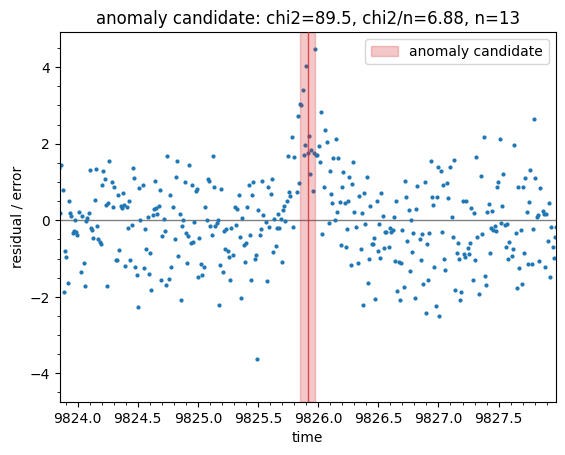

In [6]:
tf_result.plot(zoom=True, zoom_pad=2.0)
plt.show()